# SDXL + SAE Slider Generation Demo

**Before you run:**
1. In the **Configuration** cell below, set your local SDXL weights path and SAE checkpoint directory.
2. Start Jupyter from the repository root, or set `PROJECT_ROOT` to the `ksaedit` root so `SDLens`, `training`, and `utils` import correctly.
3. A GPU with enough VRAM is required.

In [ ]:
# --- Configuration ---
import os
PROJECT_ROOT = os.getcwd()
if not os.path.isdir(os.path.join(PROJECT_ROOT, "training")):
    _up = os.path.abspath(os.path.join(PROJECT_ROOT, ".."))
    if os.path.isdir(os.path.join(_up, "training")):
        PROJECT_ROOT = _up

PRETRAINED_MODEL = "/path/to/model/stabilityai/stable-diffusion-xl-base-1.0"
CHECKPOINTS_SAE = "/path/to/checkpoints"  # directory that contains a final/ subfolder

DEVICE = "cuda:0"

NUM_INFERENCE_STEPS = 50
GUIDANCE_SCALE = 7.5
SEED = 29425
IMAGE_PROMPT = "A photo of a composed Moroccan man wearing a woolen scarf, with a blurred background."
ATTR_TXT = "big smile"
LAMBDA_VALUES = (0.0, 0.1, 0.15, 0.25, 0.30)


In [2]:
import sys
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import matplotlib.pyplot as plt
from SDLens import HookedStableDiffusionXLPipeline
from training.k_sparse_autoencoder import SparseAutoencoder
from utils.hooks import add_feature_on_text_prompt, minus_feature_on_text_prompt

dtype = torch.float32
device = DEVICE


In [ ]:
BLOCKS = [
    "text_encoder.text_model.encoder.layers.10",
    "text_encoder_2.text_model.encoder.layers.28",
]


def modulate_hook_prompt(sae, steering_vec, block):
    n = [0]

    def hook_function(*args, **kwargs):
        n[0] += 1
        if n[0] == 1:
            return add_feature_on_text_prompt(sae, steering_vec, *args, **kwargs)
        return minus_feature_on_text_prompt(sae, steering_vec, *args, **kwargs)

    return hook_function


def activation_modulation_across_prompt(
    pipe,
    sae,
    steer_prompt,
    image_prompt,
    strength,
    steps,
    guidance_scale,
    seed,
    blocks_to_save=BLOCKS,
):
    gen_prompt = [image_prompt] if isinstance(image_prompt, str) else image_prompt

    _, cache = pipe.run_with_cache(
        steer_prompt,
        positions_to_cache=blocks_to_save,
        save_input=True,
        save_output=True,
        num_inference_steps=1,
        guidance_scale=guidance_scale,
        generator=torch.Generator(device="cpu").manual_seed(seed),
    )
    diff1 = cache["output"][blocks_to_save[0]][:, 0, :].squeeze(0)
    diff2 = cache["output"][blocks_to_save[1]][:, 0, :].squeeze(0)
    diff = torch.cat([diff1, diff2], dim=-1)

    activated = sae.encode_without_topk(diff)
    steering_vec = (activated * strength) @ sae.decoder.weight.T

    if strength == 0:
        out = pipe(
            gen_prompt,
            num_inference_steps=steps,
            guidance_scale=guidance_scale,
            generator=torch.Generator(device="cpu").manual_seed(seed),
        )
    else:
        out = pipe.run_with_hooks(
            gen_prompt,
            position_hook_dict={
                b: modulate_hook_prompt(sae, steering_vec, b) for b in blocks_to_save
            },
            num_inference_steps=steps,
            guidance_scale=guidance_scale,
            generator=torch.Generator(device="cpu").manual_seed(seed),
        )

    return out.images[0]


In [4]:
pipe = HookedStableDiffusionXLPipeline.from_pretrained(PRETRAINED_MODEL, torch_dtype=dtype)
pipe.set_progress_bar_config(disable=True)
pipe.to(device)
sae_path = os.path.join(CHECKPOINTS_SAE, "final")
sae = SparseAutoencoder.load_from_disk(sae_path).to(device, dtype=dtype)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/opt/data/private/ywx/ksaedit/training/k_sparse_autoencoder.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(os.path.join(path, PATH_TO_WEIGHTS),

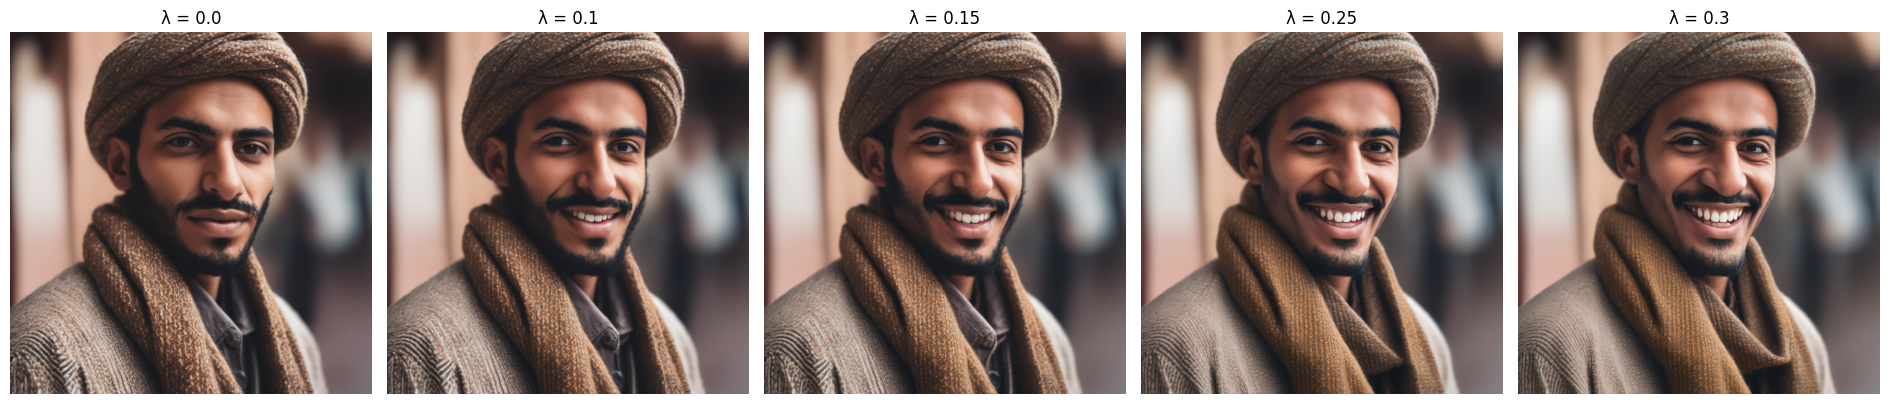

In [5]:
torch.cuda.empty_cache()
n = len(LAMBDA_VALUES)
fig, axes = plt.subplots(1, n, figsize=(3.8 * n, 4.2))
axes = [axes] if n == 1 else axes

with torch.no_grad():
    for ax, lam in zip(axes, LAMBDA_VALUES):
        image = activation_modulation_across_prompt(
            pipe,
            sae,
            ATTR_TXT,
            IMAGE_PROMPT,
            lam,
            NUM_INFERENCE_STEPS,
            GUIDANCE_SCALE,
            SEED,
        )
        ax.imshow(image)
        ax.set_title(f"λ = {lam}")
        ax.axis("off")

plt.tight_layout()
plt.show()
